In [1]:
import cfe
import scanpy as sc

cfe.settings.backend = "python_function"
cfe.logger.setLevel("INFO")

[2025年03月07日 17时09分19秒] INFO                                                                                 
                                          _____     _ _ ______    _       ______            _                      
                                         / ____|   | | |  ____|  | |     |  ____|          | |                     
                                        | |     ___| | | |__ __ _| |_ ___| |__  __  ___ __ | | ___  _ __ ___ _ __  
                                        | |    / _ \ | |  __/ _` | __/ _ \  __| \ \/ / '_ \| |/ _ \| '__/ _ \ '__| 
                                        | |___|  __/ | | | | (_| | ||  __/ |____ >  <| |_) | | (_) | | |  __/ |    
                                         \_____\___|_|_|_|  \__,_|\__\___|______/_/\_\ .__/|_|\___/|_|  \___|_|    
                                                                                     | |                           
                                                                              

数据

In [2]:
# 读取scvelo的pancreas数据
adata = sc.read_h5ad("../tests/data/bifurcating.h5ad")
fadata = cfe.data.FateAnnData.from_anndata(adata)
fadata.layers["expression"] = fadata.layers["spliced"]
fadata.layers["count"] = fadata.layers["spliced"]

basis = "umap"
# sc.pp.subsample(fadata, n_obs=100)
fadata.obs.index = [f"cell_{i:03d}" for i in range(fadata.shape[0])]

fadata

AnnData object with n_obs × n_vars = 1000 × 250
    obs: 'cell_id', 'from', 'to', 'time', 'lineage', 'global_time', 'lin_time_sC -> sEndC', 'lin_time_sA -> sB', 'lin_time_sB -> sBmid', 'lin_time_sBmid -> sC', 'lin_time_sD -> sEndD', 'lin_time_sBmid -> sD'
    uns: 'endpoints', 'gt_velocities', 'lineage_colors', 'startpoints', 'cfe'
    obsm: 'X_emb', 'X_umap'
    layers: 'spliced', 'unspliced', 'expression', 'count'

In [3]:
fadata.obs["lineage"].value_counts()

lineage
sA -> sB       341
sC -> sEndC    240
sB -> sBmid    133
sD -> sEndD    122
sBmid -> sC     86
sBmid -> sD     78
Name: count, dtype: int64

In [4]:
import pandas as pd

# 手动添加参考里程碑
milestone_network = pd.DataFrame(
    data=[
        ["sA -> sB", "sB -> sBmid"],
        ["sB -> sBmid", "sBmid -> sC"],
        ["sB -> sBmid", "sBmid -> sD"],
        ["sBmid -> sC", "sC -> sEndC"],
        ["sBmid -> sD", "sD -> sEndD"],
        ],
    columns=["from", "to"]
)

fadata.add_trajectory_mannually(milestone_network, cluster_key="lineage")

AnnData object with n_obs × n_vars = 1000 × 250
    obs: 'cell_id', 'from', 'to', 'time', 'lineage', 'global_time', 'lin_time_sC -> sEndC', 'lin_time_sA -> sB', 'lin_time_sB -> sBmid', 'lin_time_sBmid -> sC', 'lin_time_sD -> sEndD', 'lin_time_sBmid -> sD', 'milestone_color', 'milestone'
    uns: 'endpoints', 'gt_velocities', 'lineage_colors', 'startpoints', 'cfe', 'milestone_colors', 'milestone_color_colors'
    obsm: 'X_emb', 'X_umap', 'milestone_network_emb'
    layers: 'spliced', 'unspliced', 'expression', 'count'

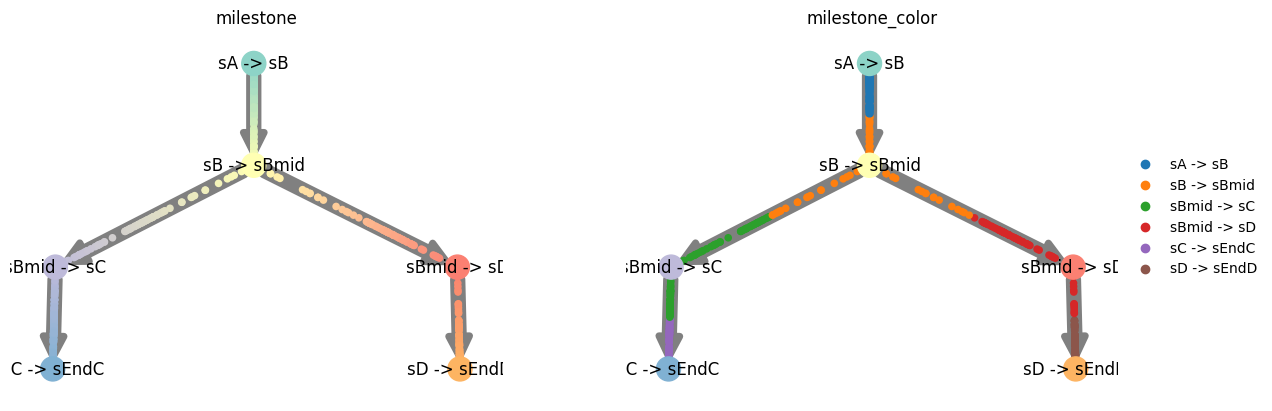

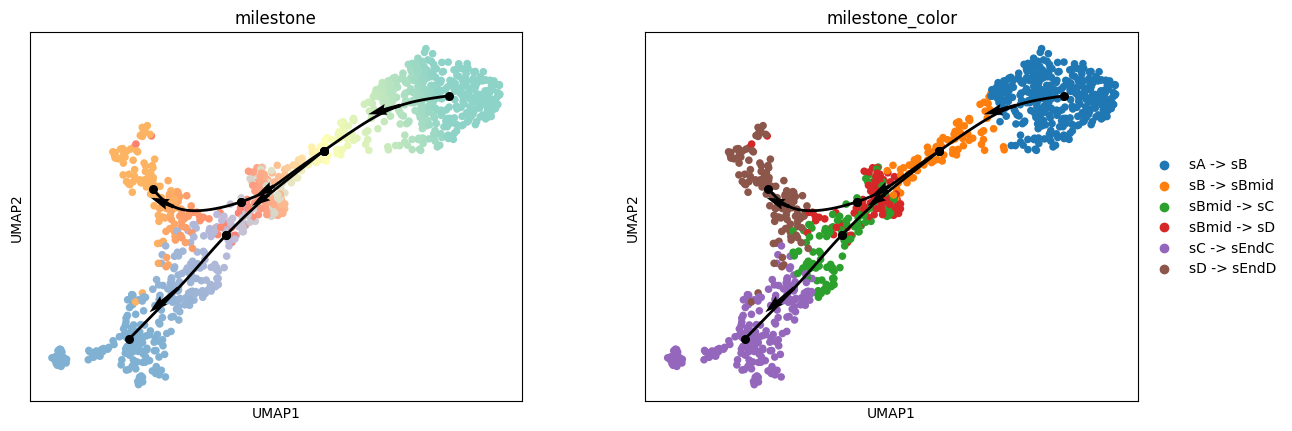

In [5]:
cluster_key = "milestone_color"
fadata.group_onto_nearest_milestones(cluster_key=cluster_key) # new cluster color

cluster_key_list = ["milestone", cluster_key]
cfe.plot.plot_graph(fadata, color=cluster_key_list)
cfe.plot.plot_trajectory(fadata, basis=basis, color=cluster_key_list)
fadata

[2025年03月07日 17时09分41秒] INFO     Loaded function: <function cf_paga at 0x77da4c1536d0> from                  
                                       /home/huang/PyCode/scRNA/CellFateExplorer/CellFateExplorer/cfe/method/functi
                                       on/cf_paga.py                                                               
                        INFO     method_backend: <cfe.method.fate_function_backend.FunctionBackend object at       
                                 0x77da574ae740>                                                                   
Normalized count data: X, spliced, unspliced.
Logarithmized X.
[2025年03月07日 17时09分51秒] INFO     Loaded function: <function cf_comp1 at 0x77da44766b90> from                 
                                       /home/huang/PyCode/scRNA/CellFateExplorer/CellFateExplorer/cfe/method/functi
                                       on/cf_comp1.py                                                              
                     

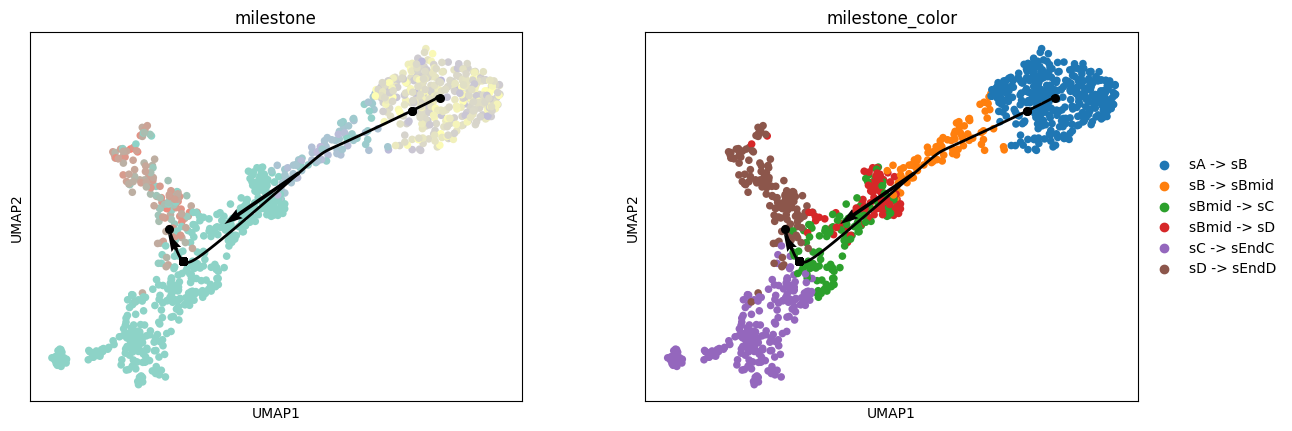

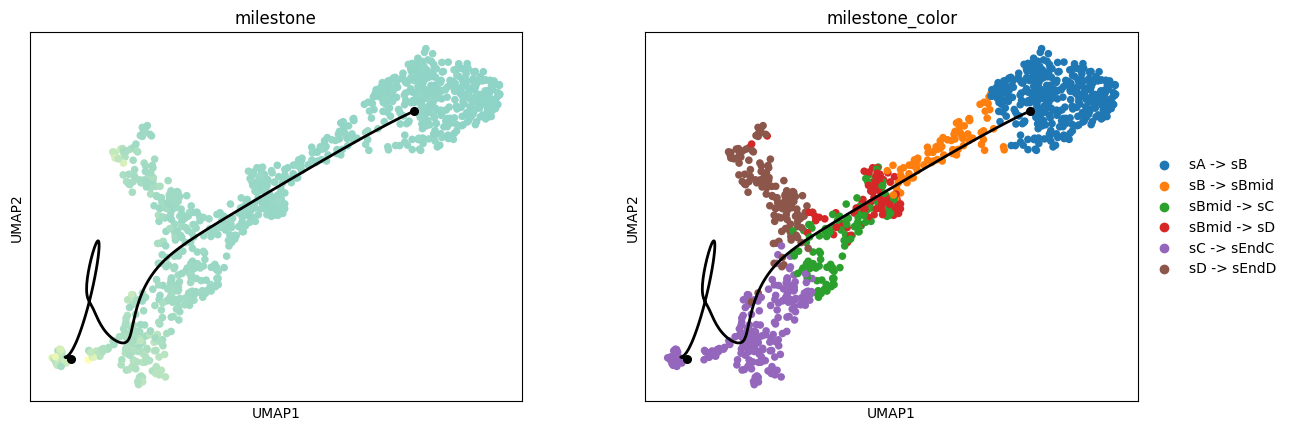

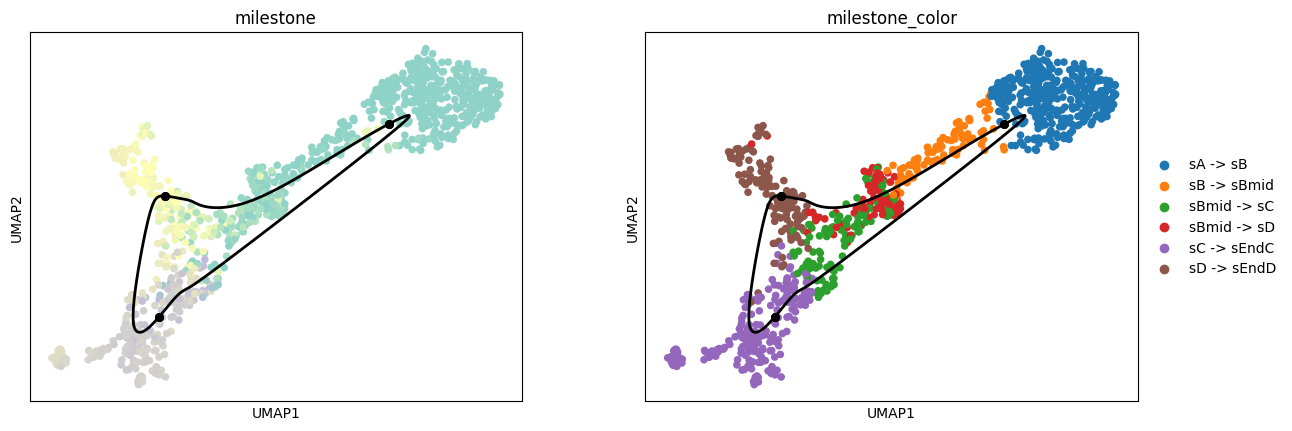

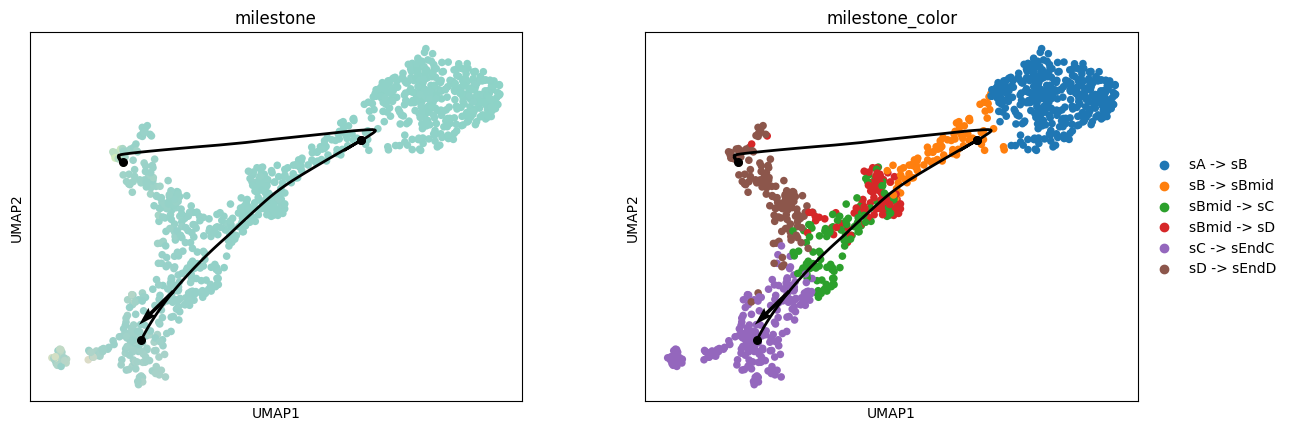

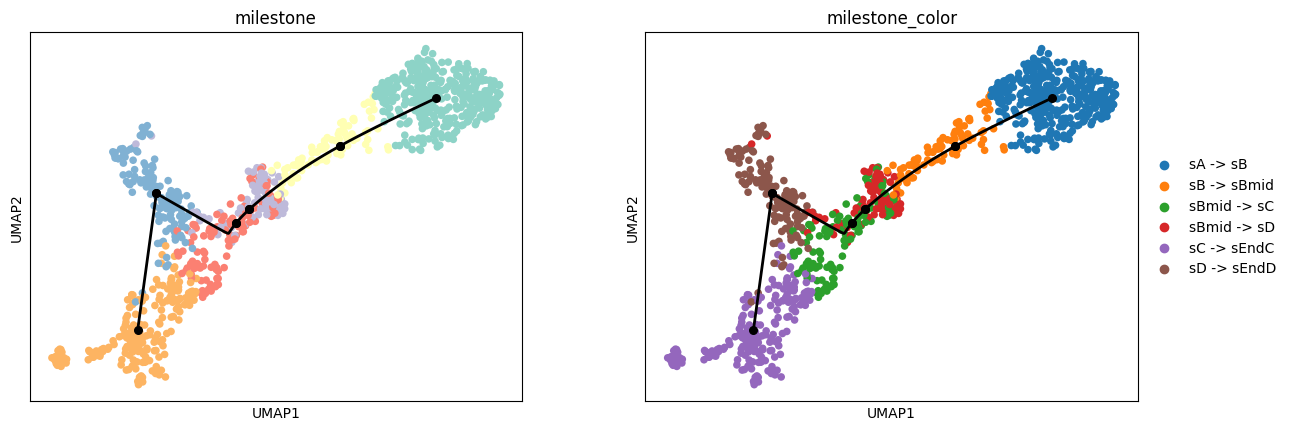

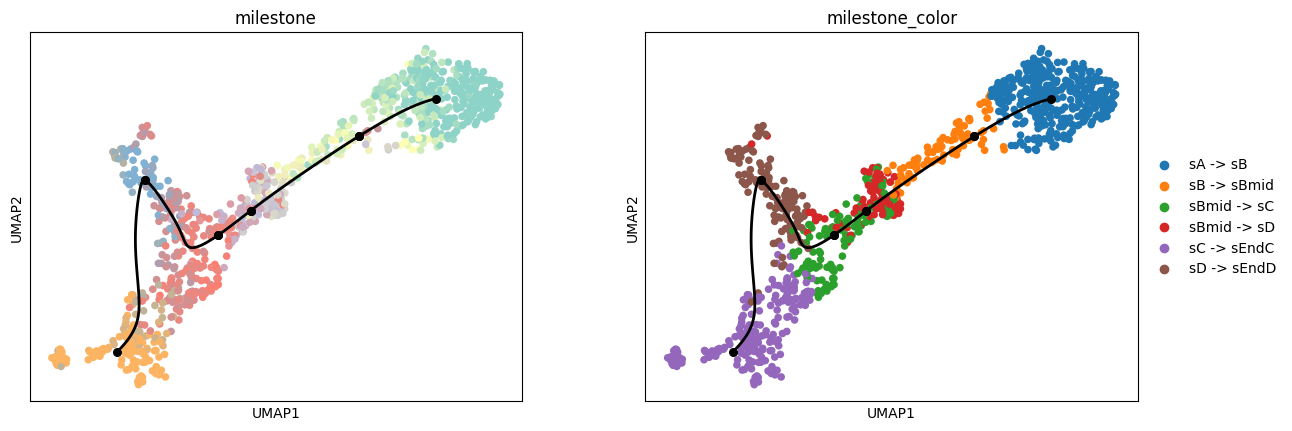

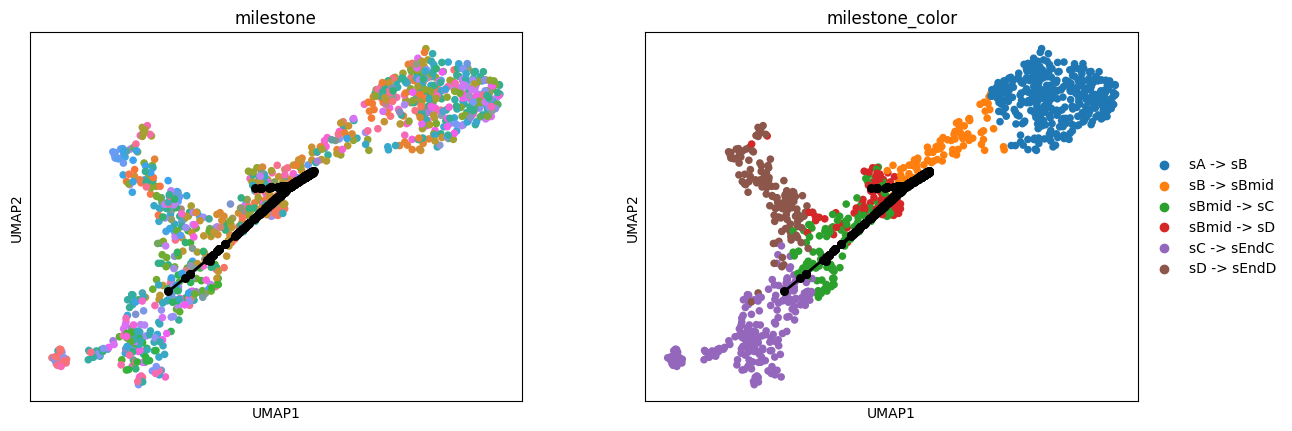

In [6]:
prior_information = {
    "start_id": fadata.obs.index[0],
    "groups_id": fadata.obs[cluster_key].tolist()
}
parameters = {"filter_features": False, "connectivity_cutoff": 0.3}
fadata.add_prior_information(**prior_information)  # add prior information to fadata


method_name_list = ["paga", "comp1", "angle", "state_comp", "cluster_mst", "projection_mst", "graph_mst"]

for method_name in method_name_list:
    method = cfe.method.FateMethod(method_name=method_name)

    method.infer_trajectory(fadata)

    cfe.plot.plot_trajectory(fadata, basis="umap", color=cluster_key_list)